# Design 2: cyclic (von Mises) environment

From `literature-notes/main-project-idea.txt`: same as Design 1, but instead of drawing songs uniformly at random, the 100 songs are placed at equally-spaced positions around a circle, and the next song is drawn from a von Mises distribution (the circular analogue of a Gaussian) whose center sweeps cyclically around that circle over time.

Formalization (`run_simulation.py`):
- `sweep_center(trial, ...)`: the moving center mu(t), in radians. `sweep_type="rotate"` sweeps steadily in one direction (num_cycles full revolutions over the run); `sweep_type="oscillate"` swings back and forth instead.
- `von_mises_weights(angles, mu, kappa)`: sampling weight for each song given the current center and concentration `kappa` (higher = tighter spotlight).
- `run_design2(...)`: draws each exposure from this distribution, otherwise identical to Design 1 (aesthetic_basis on repeat exposures, rolling mean).

Defaults used below: `num_cycles=10`, `sweep_type="rotate"`, `kappa=4.0` over `num_exposures=10000` — adjust and re-run if these don't look right.

In [ ]:
import math
import sys
sys.path.insert(0, "..")
import matplotlib.pyplot as plt

from run_simulation import sweep_center, von_mises_weights, run_design2

NUM_SONGS = 30
NUM_EXPOSURES = 10000
NUM_CYCLES = 40
KAPPA = 0.5
SWEEP_TYPE = "oscillate"

angles = [2 * math.pi * i / NUM_SONGS for i in range(NUM_SONGS)]
period = NUM_EXPOSURES / NUM_CYCLES

## Controller visualization
Six snapshots across one cycle, showing the 100 songs on the circle, the von Mises sampling-probability density (bars), and the current center (red line).

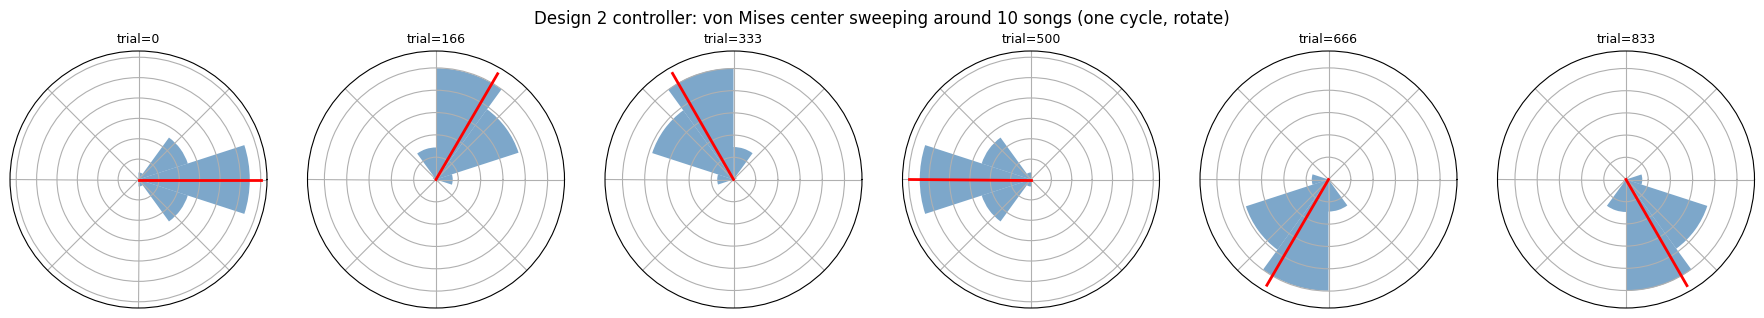

In [2]:
n_snapshots = 6
snapshot_trials = [int(k * period / n_snapshots) for k in range(n_snapshots)]

fig, axes = plt.subplots(1, n_snapshots, figsize=(3 * n_snapshots, 3.2),
                          subplot_kw={"projection": "polar"})
for ax, t in zip(axes, snapshot_trials):
    mu = sweep_center(t, NUM_EXPOSURES, NUM_CYCLES, SWEEP_TYPE)
    weights = von_mises_weights(angles, mu, KAPPA)
    ax.bar(angles, weights, width=2 * math.pi / NUM_SONGS, color="steelblue", alpha=0.7)
    ax.plot([mu, mu], [0, max(weights) * 1.1], color="red", linewidth=2)
    ax.set_title(f"trial={t}", fontsize=9)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
fig.suptitle(f"Design 2 controller: von Mises center sweeping around {NUM_SONGS} songs (one cycle, {SWEEP_TYPE})")
fig.tight_layout()
fig.savefig("../results/figures/design2_controller_snapshots.png", dpi=150)

## Resulting aesthetic_basis time series

In [3]:
df = run_design2(num_songs=NUM_SONGS, num_exposures=NUM_EXPOSURES,
                  kappa=KAPPA, num_cycles=NUM_CYCLES, sweep_type=SWEEP_TYPE,
                  config_path="../config.yaml",
                  output_path="../results/data/design2_cyclic_timeseries.csv")
df.tail()

,predicted_song_id,predicted_activation,actual_song_id,actual_activation,aesthetic_basis,trial,complexity,mu,aesthetic_basis_rolling_mean
9985,song_007,3.730309,song_009,3.752856,0.022547,9995,10,62.800437,0.631322
9986,song_000,3.934700,song_001,2.922271,1.012428,9996,1,62.806720,0.665244
9987,song_000,3.987338,song_009,2.872107,1.115231,9997,10,62.813004,0.667923
9988,song_000,3.806467,song_000,3.141254,0.665213,9998,2,62.819287,0.632432
9989,song_000,3.410912,song_000,2.884787,0.526125,9999,2,62.825570,0.606524


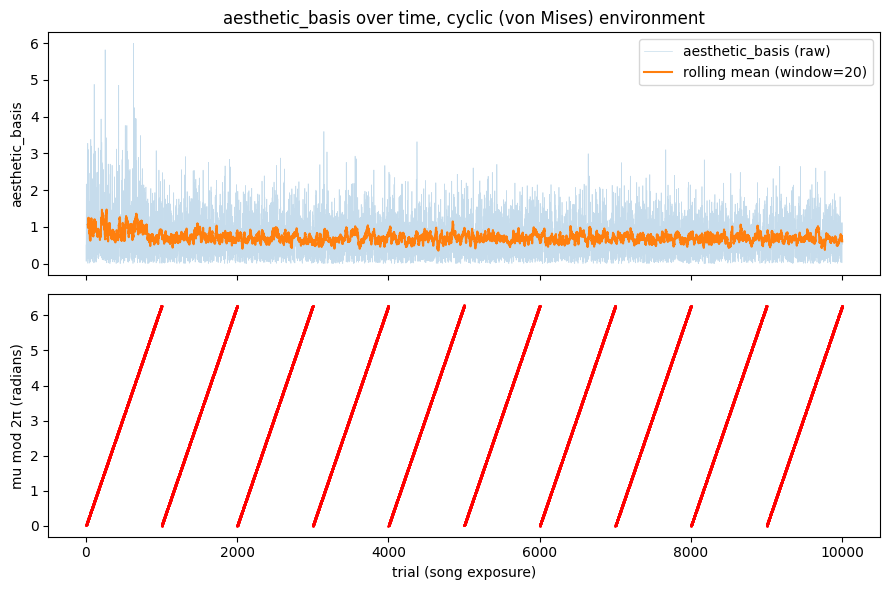

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.plot(df["trial"], df["aesthetic_basis"], alpha=0.25, linewidth=0.5, label="aesthetic_basis (raw)")
ax1.plot(df["trial"], df["aesthetic_basis_rolling_mean"], linewidth=1.5, label="rolling mean (window=20)")
ax1.set_ylabel("aesthetic_basis")
ax1.set_title("aesthetic_basis over time, cyclic (von Mises) environment")
ax1.legend()

mu_wrapped = df["mu"] % (2 * math.pi)
ax2.scatter(df["trial"], mu_wrapped, color="red", s=1)
ax2.set_ylabel("mu mod 2π (radians)")
ax2.set_xlabel("trial (song exposure)")

fig.tight_layout()
fig.savefig("../results/figures/design2_cyclic_timeseries.png", dpi=150)

Compare the top panel's fluctuations to the bottom panel's mu(t) sweep: does aesthetic_basis show any systematic relationship to sweep phase (e.g. spikes when mu crosses certain songs), or does it look statistically similar to Design 1's uniform-environment result?